正規分布

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

Running on PyMC v5.27.0
Running on ArviZ v0.23.0


([<matplotlib.axis.XTick at 0x72c7b213e390>,
 [Text(4.0, 0, '4.0'),
  Text(4.2, 0, '4.2'),
  Text(4.4, 0, '4.4'),
  Text(4.6000000000000005, 0, '4.6'),
  Text(4.800000000000001, 0, '4.8'),
  Text(5.000000000000001, 0, '5.0'),
  Text(5.200000000000001, 0, '5.2'),
  Text(5.400000000000001, 0, '5.4'),
  Text(5.600000000000001, 0, '5.6'),
  Text(5.800000000000002, 0, '5.8'),
  Text(6.000000000000002, 0, '6.0')])

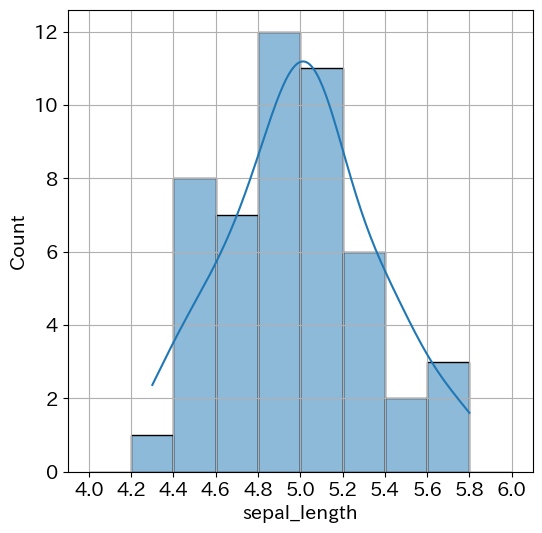

In [3]:
# データ・セット
df = sns.load_dataset('iris')
df1 = df.query('species == "setosa"')

bins = np.arange(4.0, 6.2, 0.2)

sns.histplot(df1, x='sepal_length', bins=bins, kde=True)
plt.xticks(bins)

Text(0.5, 1.0, '正規分布関数のグラフ')

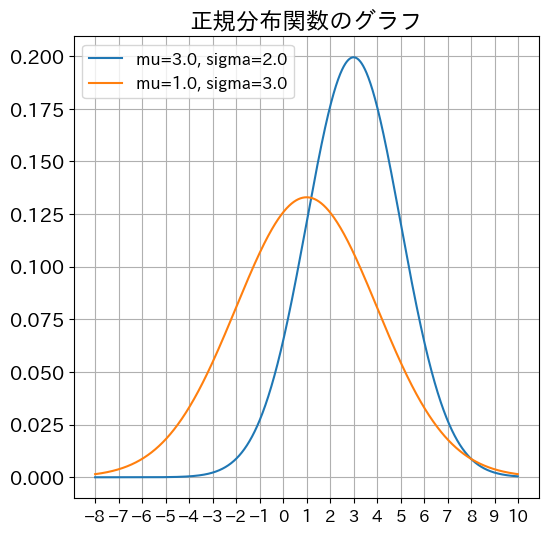

In [5]:
def norm(x,mu,sigma):
    return np.exp(-((x-mu)/sigma)**2/2) / (np.sqrt(2*np.pi)*sigma)

mu1, sigma1 = 3.0, 2.0
mu2, sigma2 = 1.0, 3.0

# 2つの正規分布関数で±3sigmaまではいるように計算
x = np.arange(-8.0, 10.0, 0.01)

xticks = np.arange(-8.0, 11.0, 1.0)

plt.plot(x, norm(x, mu1, sigma1), label=f"mu={mu1}, sigma={sigma1}")
plt.plot(x, norm(x, mu2, sigma2), label=f"mu={mu2}, sigma={sigma2}")
plt.xticks(xticks, fontsize=12)
plt.legend(fontsize=12)
plt.title(f"正規分布関数のグラフ")


In [11]:
mu = 0.0
sigma = 1.0

model4 = pm.Model()
# モデル定義
with model4:
    x = pm.Normal('x', mu=mu, sigma=sigma)

# 事前分布からサンプリング
with model4:
    prior_samples4 = pm.sample_prior_predictive(random_seed=42)

x_samples4 = prior_samples4['prior']['x'].values
print(x_samples4[:,:100])

Sampling: [x]


[[ 0.418  0.606  0.029 -1.084  1.464  0.291 -1.331 -0.035  0.280  0.107
  -1.921  1.579  1.006  0.451 -0.593  0.094  1.852 -0.256 -0.283  0.416
  -1.089 -1.967  0.887 -1.328 -0.132 -0.362  0.782  0.283 -1.006  0.019
  -1.243  2.603  0.151 -0.516 -0.220  0.402  1.361  0.743  0.937  0.175
   1.525  0.098 -1.165  0.524 -1.066 -0.311  0.556 -0.100 -0.258 -1.590
  -1.815  0.536  1.271 -0.554  1.724 -0.312  0.063  1.382  0.585 -0.510
   0.251  0.406  0.866 -0.534 -0.039  1.143 -0.464  2.267 -0.529  0.325
  -0.154 -0.820 -1.203  0.095 -1.362  0.277  0.307 -1.404 -1.539  1.597
   1.268 -0.744 -1.379 -0.373  0.225 -0.797 -0.190  0.405 -1.567  1.622
  -0.559  1.285 -0.649  0.642  2.170 -0.549  0.032 -0.744  1.306  0.870]]


In [12]:
value_counts4 = pd.DataFrame(x_samples4.reshape(-1)).value_counts().sort_index()
print(value_counts4)

0     
-4.093    1
-2.844    1
-2.458    1
-2.166    1
-2.081    1
         ..
2.208     1
2.249     1
2.267     1
2.528     1
2.603     1
Name: count, Length: 500, dtype: int64


In [13]:
# サンプリング結果の分析
summary4 = az.summary(prior_samples4, kind='stats')
display(summary4)

,mean,sd,hdi_3%,hdi_97%
x,0.009,0.963,-1.590,1.900


Text(0.5, 1.0, '正規分布 mu=0.0, sigma=1.0')

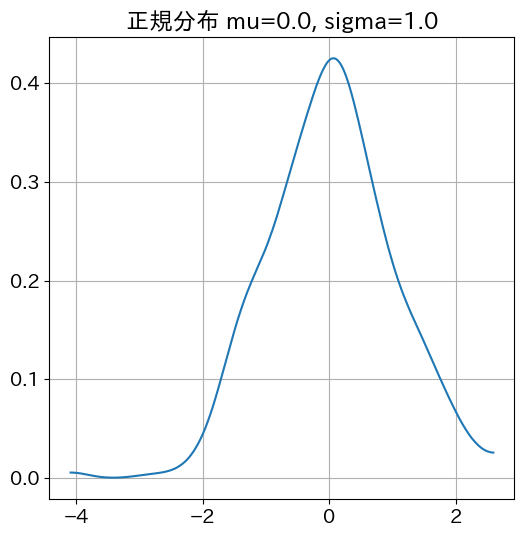

In [14]:
ax = az.plot_dist(x_samples4) # 値がい浮動小数点の場合は自動で連続分布からサンプリングしたものと判断して連続関数で近似する
ax.set_title(f"正規分布 mu={mu}, sigma={sigma}")

Text(0.5, 1.0, '正規分布 mu=0.0, sigma=1.0')

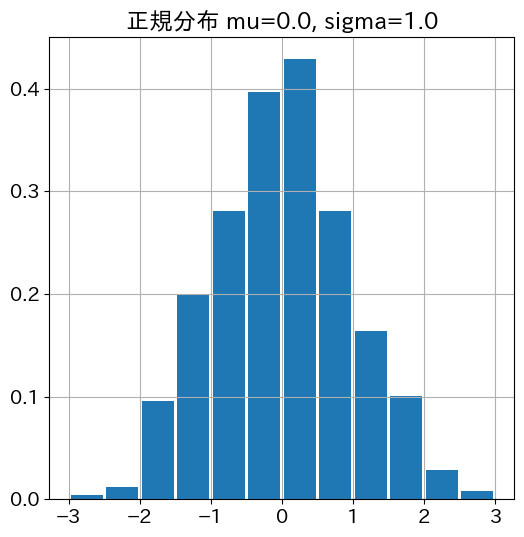

In [15]:
# ヒストグラム表示
bins = np.arange(-3, 3.5, 0.5)
ax = az.plot_dist(x_samples4, kind="hist", hist_kwargs={'bins':bins})
plt.xticks(np.arange(-3, 4, 1))
ax.set_title(f"正規分布 mu={mu}, sigma={sigma}")

In [16]:
mu = 3.0
sigma = 2.0

model5 = pm.Model()

# モデル定義
with model5:
    x = pm.Normal('x', mu=mu, sigma=sigma)

# 事前分布からのサンプリング
with model5:
    prior_samples5 = pm.sample_prior_predictive(random_seed=42)

x_samples5 = prior_samples5['prior']['x'].values
print(x_samples5[:,:100])

Sampling: [x]


[[ 3.837  4.211  3.058  0.832  5.928  3.581  0.338  2.931  3.561  3.215
  -0.842  6.157  5.012  3.902  1.813  3.188  6.704  2.488  2.434  3.832
   0.822 -0.935  4.775  0.344  2.737  2.276  4.564  3.565  0.988  3.037
   0.514  8.207  3.303  1.969  2.561  3.805  5.723  4.486  4.874  3.351
   6.050  3.196  0.670  4.047  0.869  2.378  4.112  2.801  2.485 -0.179
  -0.630  4.072  5.543  1.892  6.449  2.376  3.127  5.764  4.169  1.980
   3.503  3.812  4.731  1.932  2.922  5.285  2.073  7.534  1.943  3.649
   2.691  1.361  0.594  3.191  0.277  3.555  3.613  0.192 -0.078  6.194
   5.537  1.511  0.242  2.254  3.450  1.406  2.620  3.810 -0.133  6.245
   1.883  5.570  1.702  4.285  7.341  1.902  3.064  1.511  5.611  4.740]]


In [17]:
value_counts5 = pd.DataFrame(x_samples5.reshape(-1)).value_counts().sort_index()
print(value_counts5)

0     
-5.186    1
-2.689    1
-1.915    1
-1.332    1
-1.162    1
         ..
7.416     1
7.499     1
7.534     1
8.057     1
8.207     1
Name: count, Length: 500, dtype: int64


In [18]:
# サンプリング結果の分析
summary5 = az.summary(prior_samples5, kind='stats')
display(summary5)

,mean,sd,hdi_3%,hdi_97%
x,3.018,1.927,-0.180,6.801


Text(0.5, 1.0, '正規分布 mu=3.0, sigma=2.0')

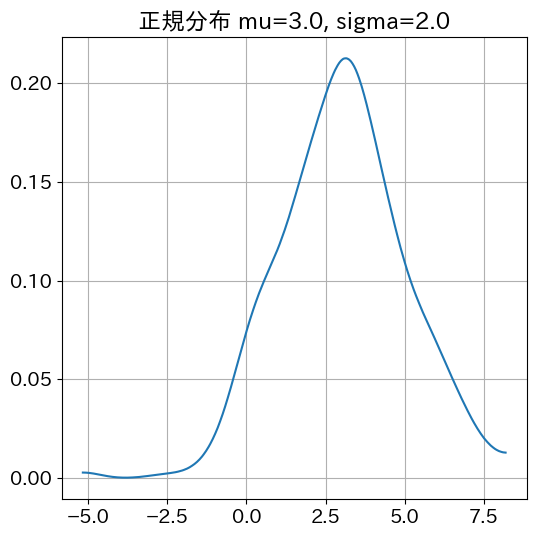

In [19]:
ax = az.plot_dist(x_samples5) # 値がい浮動小数点の場合は自動で連続分布からサンプリングしたものと判断して連続関数で近似する
ax.set_title(f"正規分布 mu={mu}, sigma={sigma}")

Text(0.5, 1.0, '正規分布 mu=3.0, sigma=2.0')

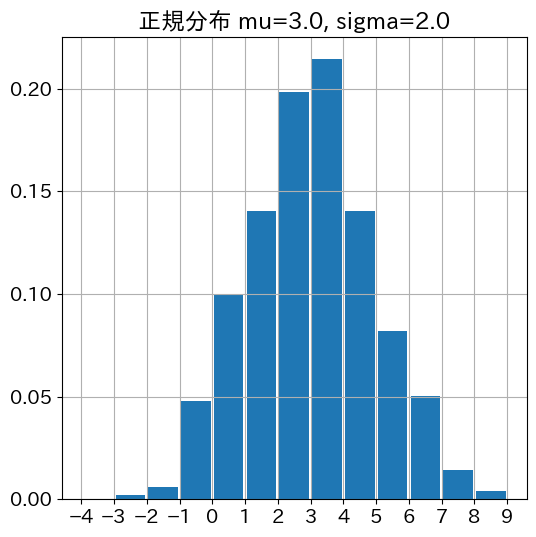

In [25]:
# ヒストグラム表示
bins = np.arange(-4, 9.5, 1)
ax = az.plot_dist(x_samples5, kind="hist", hist_kwargs={'bins':bins})
plt.xticks(np.arange(-4, 9.5, 1))
ax.set_title(f"正規分布 mu={mu}, sigma={sigma}")